## FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

### Objective:
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset. 
### Dataset:
The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import Holt
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

### Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [2]:
df = pd.read_csv("exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
print("Shape of dataset:", df.shape)
print("\nDataset Information:")
df.info()

Shape of dataset: (7588, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [5]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.head()

,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


In [6]:
df = df.sort_values('date')
df.set_index('date', inplace=True)
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Ex_rate    0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2258


In [9]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


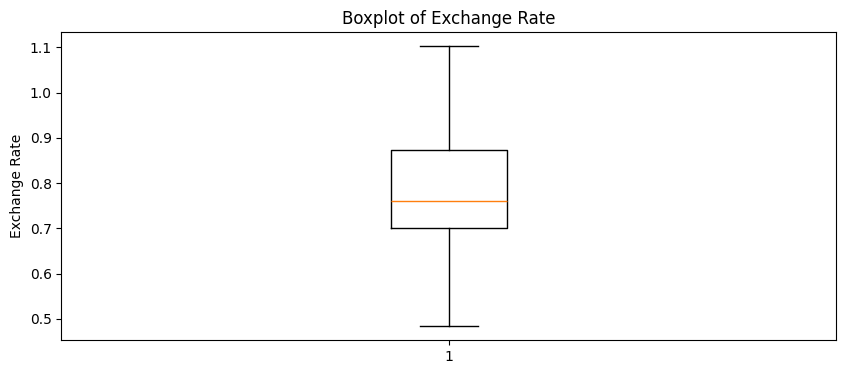

In [32]:
plt.figure(figsize=(10, 4))
plt.boxplot(df['Ex_rate'])
plt.title("Boxplot of Exchange Rate")
plt.ylabel("Exchange Rate")
plt.show()

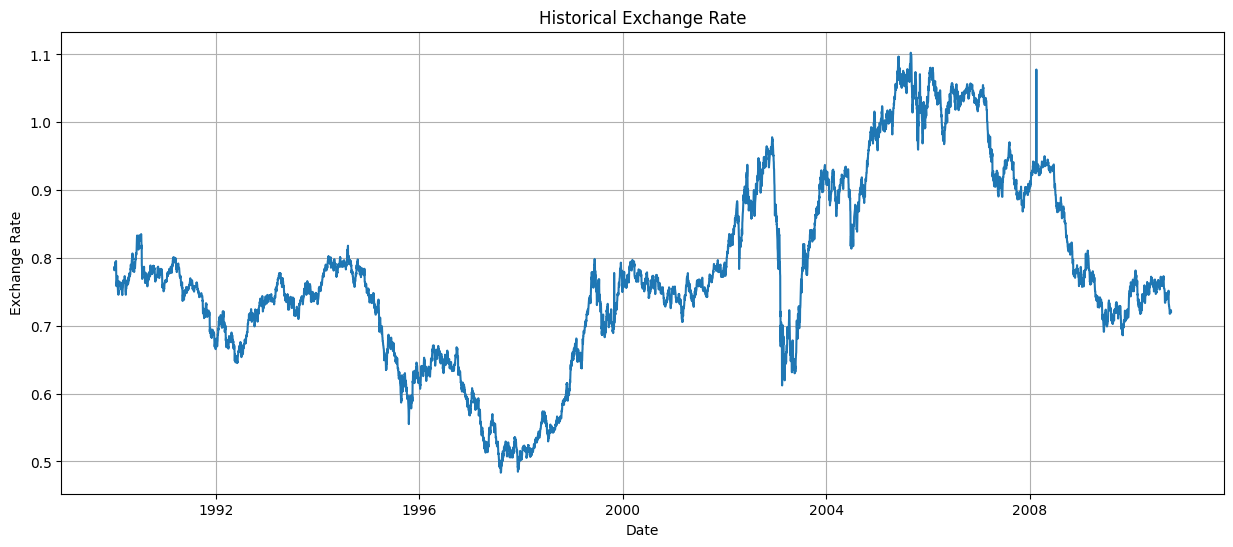

In [10]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Ex_rate'])
plt.title("Historical Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

In [11]:
result = adfuller(df['Ex_rate'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901


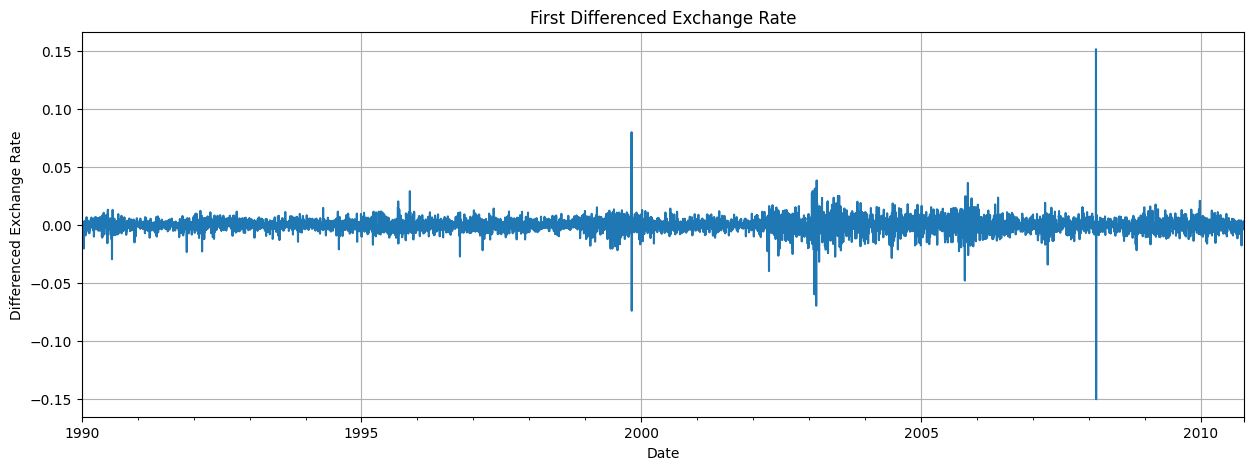

In [12]:
df['Ex_rate_diff'] = df['Ex_rate'].diff()
df['Ex_rate_diff'].plot(figsize=(15, 5))
plt.title("First Differenced Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Differenced Exchange Rate")
plt.grid(True)
plt.show()

In [13]:
result_diff = adfuller(df['Ex_rate_diff'].dropna())
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -99.39343120118629
p-value: 0.0


In [14]:
series = df['Ex_rate']
train_size = int(len(series) * 0.80)
train = series.iloc[:train_size]
test = series.iloc[train_size:]
print("Training observations:", len(train))
print("Testing observations:", len(test))
print("\nTraining period:")
print(train.index.min(), "to", train.index.max())
print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 6070
Testing observations: 1518

Training period:
1990-01-01 00:00:00 to 2006-08-14 00:00:00

Testing period:
2006-08-15 00:00:00 to 2010-10-10 00:00:00


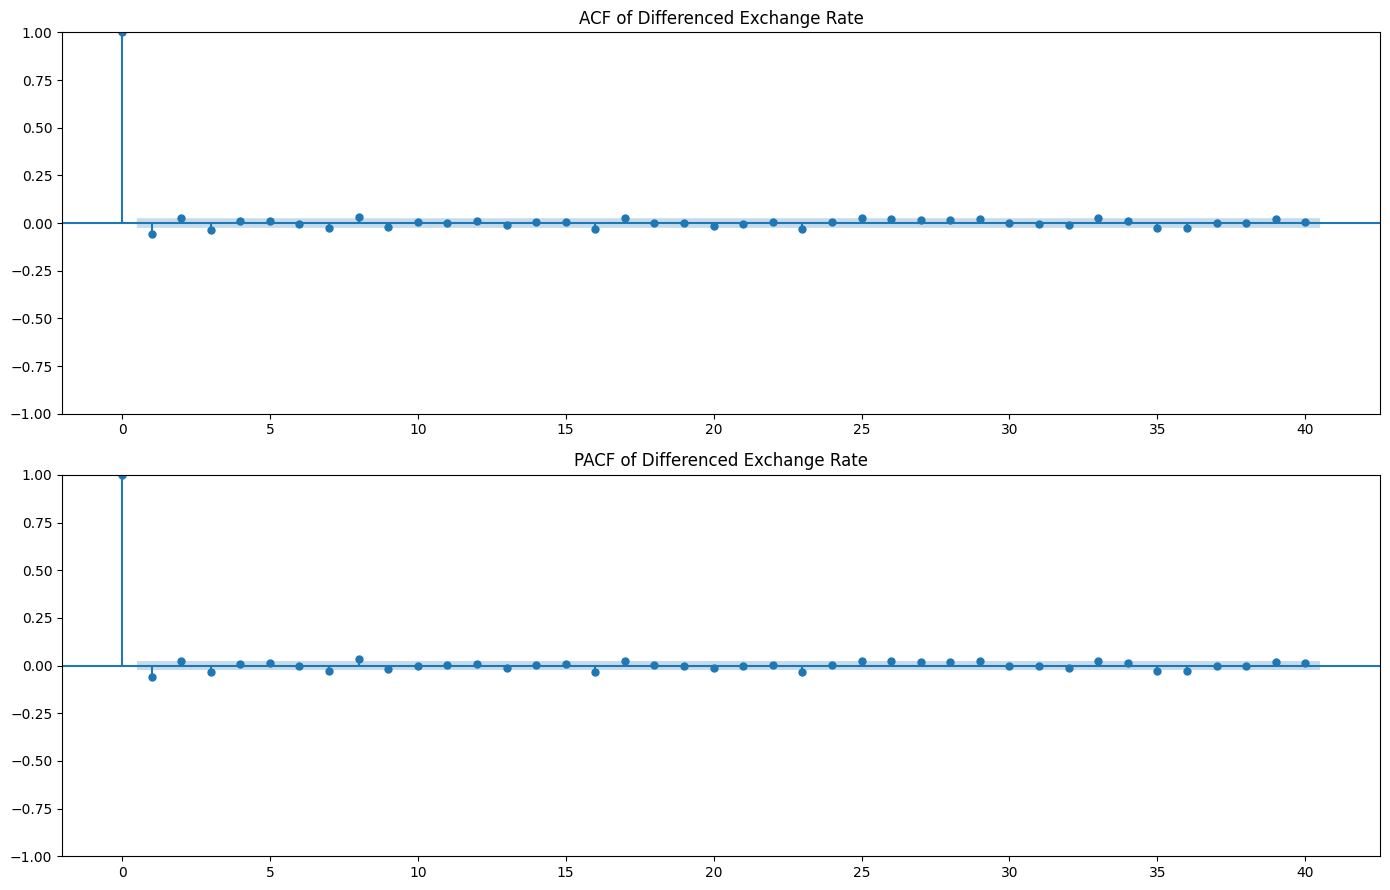

In [15]:
diff_train = train.diff().dropna()
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
plot_acf(diff_train, lags=40, ax=axes[0])
axes[0].set_title("ACF of Differenced Exchange Rate")
plot_pacf(diff_train, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Differenced Exchange Rate")
plt.tight_layout()
plt.show()

The ACF and PACF plots were examined to understand the autocorrelation structure and obtain initial values for p and q. Several candidate ARIMA models were then fitted and compared using AIC. ARIMA(1,1,1) was selected because it produced the lowest AIC among the tested models.

In [16]:
aic_results = []
for p in range(3):
    for q in range(3):
        try:
            model = ARIMA(train, order=(p, 1, q))
            fitted_model = model.fit()
            aic_results.append({
                'p': p,
                'd': 1,
                'q': q,
                'AIC': fitted_model.aic
            })
        except:
            pass
aic_df = pd.DataFrame(aic_results)
aic_df.sort_values('AIC')

,p,d,q,AIC
4,1,1,1,-45432.091583
5,1,1,2,-45429.880419
8,2,1,2,-45428.425715
6,2,1,0,-45427.648041
2,0,1,2,-45426.412388
3,1,1,0,-45425.956729
1,0,1,1,-45424.939922
0,0,1,0,-45406.255142
7,2,1,1,-45400.257795


## Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [17]:
arima_model = ARIMA(train, order=(1, 1, 1))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 16 Aug 2026   AIC                         -45432.092
Time:                        01:43:57   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

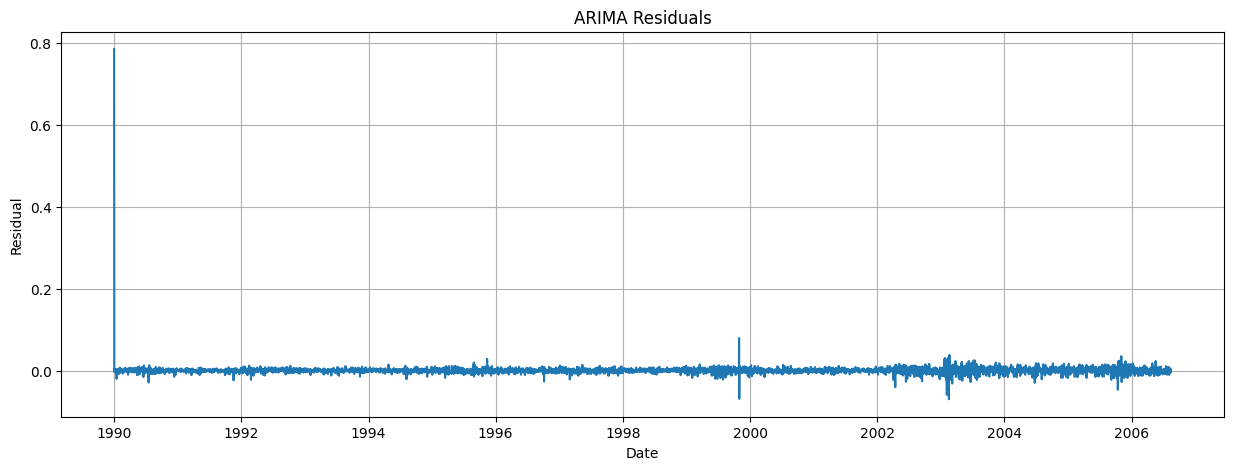

In [18]:
residuals = arima_result.resid
plt.figure(figsize=(15, 5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

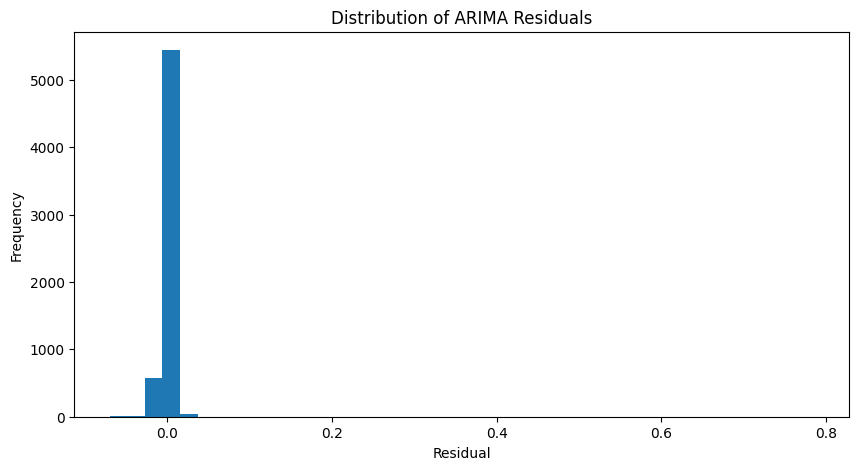

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=40)
plt.title("Distribution of ARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [20]:
ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[10, 20],
    return_df=True
)
print(ljung_box)

     lb_stat  lb_pvalue
10  1.647217   0.998399
20  5.913127   0.999010


In [21]:
arima_forecast = arima_result.forecast(steps=len(test))

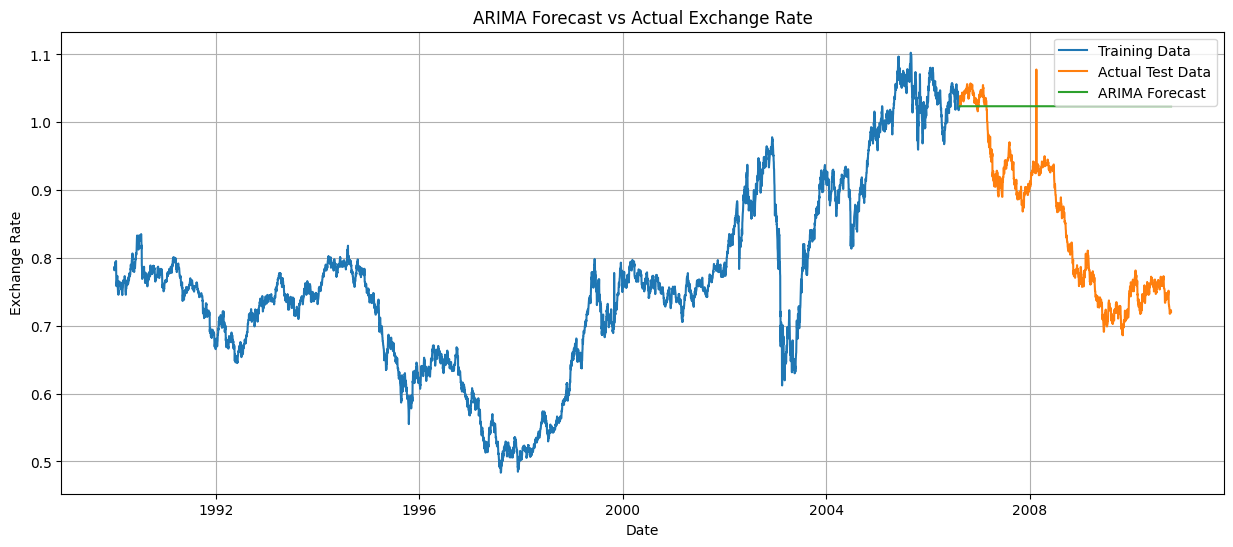

In [22]:
plt.figure(figsize=(15, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.title("ARIMA Forecast vs Actual Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
holt_model = Holt(
    train,
    damped_trend=True,
    initialization_method='estimated'
)
holt_result = holt_model.fit(optimized=True)
holt_forecast = holt_result.forecast(len(test))

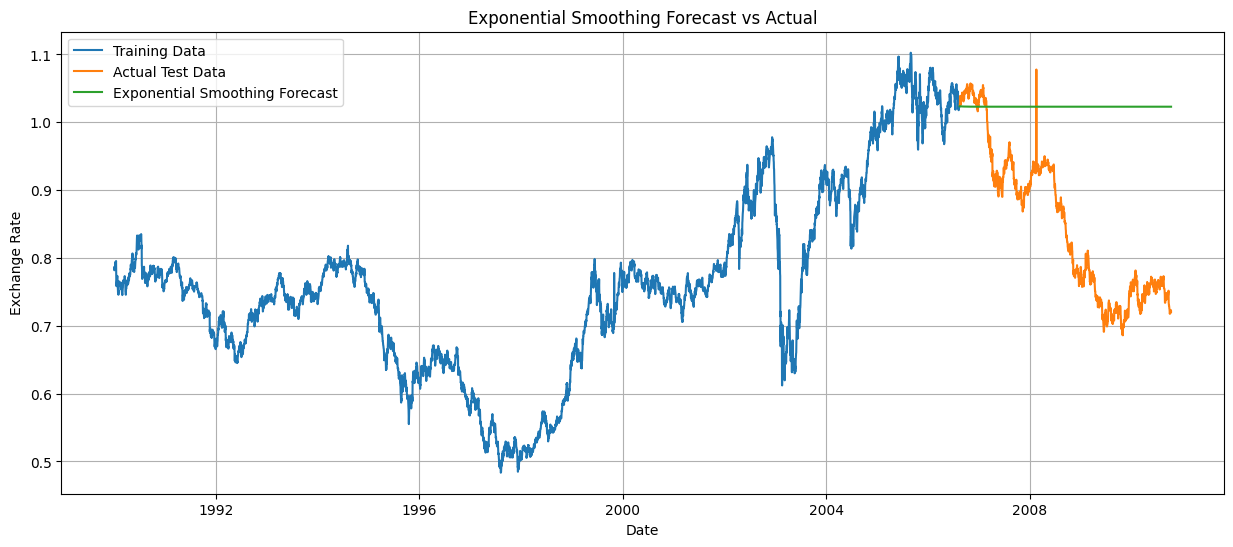

In [24]:
plt.figure(figsize=(15, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, holt_forecast, label='Exponential Smoothing Forecast')
plt.title("Exponential Smoothing Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

## Part 3: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


In [25]:
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )
    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100
    return mae, rmse, mape

In [26]:
arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test,
    arima_forecast
)

In [27]:
holt_mae, holt_rmse, holt_mape = calculate_metrics(
    test,
    holt_forecast
)

In [28]:
comparison = pd.DataFrame({
    'Model': [
        'ARIMA(1,1,1)',
        'Exponential Smoothing'
    ],
    'MAE': [
        arima_mae,
        holt_mae
    ],
    'RMSE': [
        arima_rmse,
        holt_rmse
    ],
    'MAPE (%)': [
        arima_mape,
        holt_mape
    ]
})
comparison

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1,1,1)",0.17771,0.205437,22.797966
1,Exponential Smoothing,0.17718,0.204855,22.730926


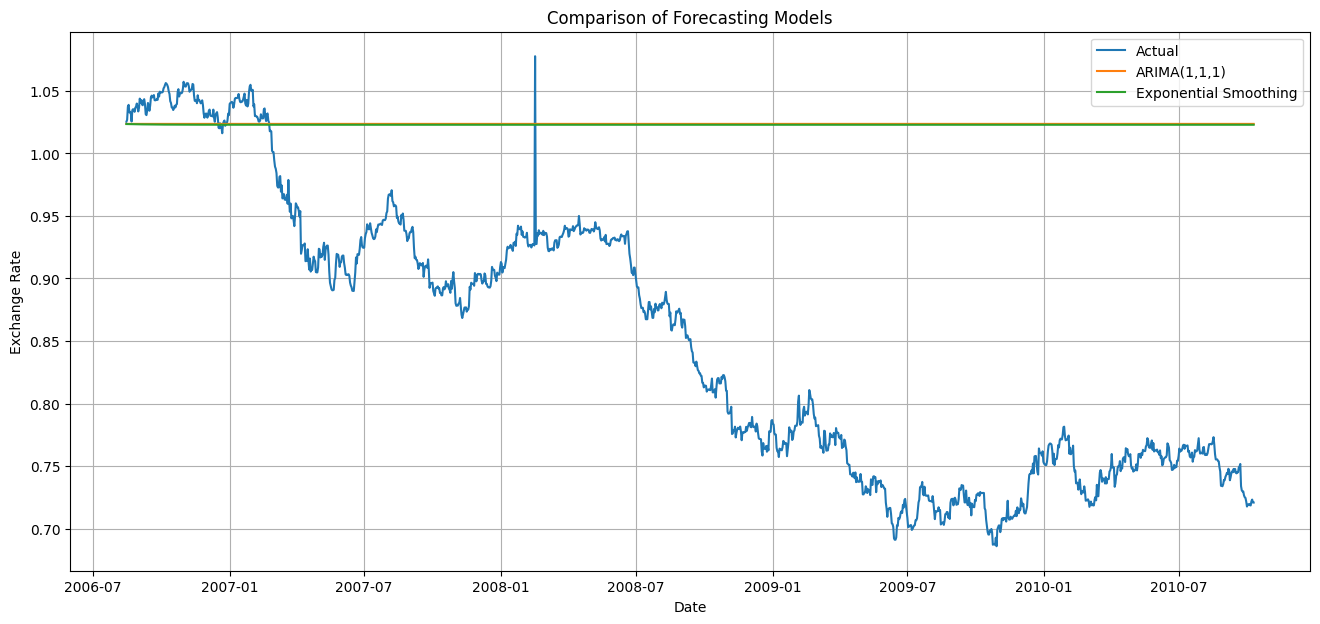

In [29]:
plt.figure(figsize=(16, 7))
plt.plot(test.index, test, label='Actual')
plt.plot(
    test.index,
    arima_forecast,
    label='ARIMA(1,1,1)'
)
plt.plot(
    test.index,
    holt_forecast,
    label='Exponential Smoothing'
)
plt.title("Comparison of Forecasting Models")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
final_model = Holt(
    series,
    damped_trend=True,
    initialization_method='estimated'
)
final_result = final_model.fit(optimized=True)
future_forecast = final_result.forecast(30)
print("Next 30 predicted exchange rates:")
print(future_forecast)

Next 30 predicted exchange rates:
2010-10-11    0.720815
2010-10-12    0.720774
2010-10-13    0.720735
2010-10-14    0.720697
2010-10-15    0.720660
2010-10-16    0.720624
2010-10-17    0.720588
2010-10-18    0.720554
2010-10-19    0.720521
2010-10-20    0.720488
2010-10-21    0.720456
2010-10-22    0.720425
2010-10-23    0.720395
2010-10-24    0.720366
2010-10-25    0.720337
2010-10-26    0.720310
2010-10-27    0.720283
2010-10-28    0.720256
2010-10-29    0.720231
2010-10-30    0.720206
2010-10-31    0.720181
2010-11-01    0.720158
2010-11-02    0.720135
2010-11-03    0.720112
2010-11-04    0.720090
2010-11-05    0.720069
2010-11-06    0.720048
2010-11-07    0.720028
2010-11-08    0.720008
2010-11-09    0.719989
Freq: D, dtype: float64


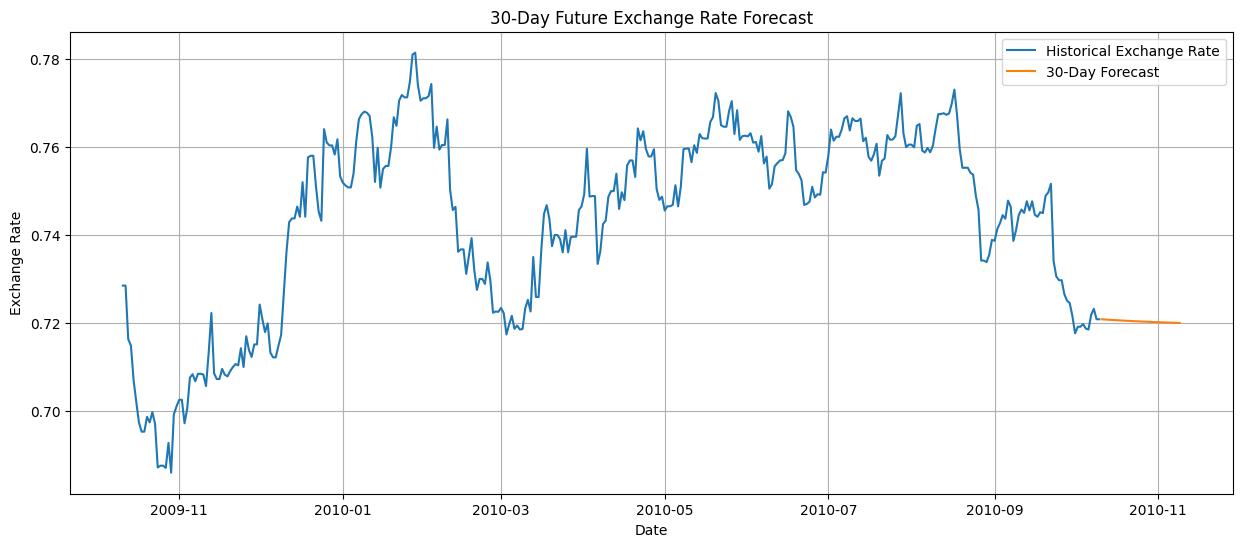

In [31]:
plt.figure(figsize=(15, 6))
plt.plot(
    series.index[-365:],
    series.iloc[-365:],
    label='Historical Exchange Rate'
)
plt.plot(
    future_forecast.index,
    future_forecast,
    label='30-Day Forecast'
)
plt.title("30-Day Future Exchange Rate Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

The exchange-rate dataset contained 7,588 daily observations from January 1990 to October 2010. The data contained no missing values or duplicate records, so no major data-cleaning procedure was required. Exploratory analysis showed that the exchange rate changed considerably over time and was not stationary in its original form.

The Augmented Dickey-Fuller test confirmed that the original series was non-stationary. After first-order differencing, the series became stationary, giving d = 1 for the ARIMA model. A comparison of different ARIMA configurations using AIC resulted in ARIMA(1,1,1) being selected.

The ARIMA residual diagnostics showed no significant remaining autocorrelation according to the Ljung-Box test, indicating that the model captured much of the temporal structure in the data.

For the 80/20 test split, ARIMA(1,1,1) achieved an MAE of approximately 0.1777, RMSE of 0.2054, and MAPE of 22.80%. The Exponential Smoothing model performed slightly better, with an MAE of approximately 0.1772, RMSE of 0.2049, and MAPE of 22.73%.

Therefore, Exponential Smoothing was the slightly better-performing model for this particular dataset and train-test split, although the difference between the two models was small. ARIMA remains useful because it explicitly models autocorrelation and differencing, while Exponential Smoothing is simpler and effective at capturing level and trend patterns.